# Deep Learning - Regresión

## Definición del problema

En este notebook vamos a desarrollar modelos de redes neuronales multicapa densas para resolver un problema de regresión. El objetivo consiste en predecir el número de usuarios del serivcio de alquiler de bicicletas de la ciudad de Seul a partir de datos meteorológicos e información de vacaciones. El banco de datos se encuentra disponible en este enlace https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

In [ ]:
# @title Cargar paquetes y módulos necesarios
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt # importamos matplotlib como plt
import seaborn as sns # importamos seaborn como sns
sns.set_style("ticks")
%config InlineBackend.figure_format = 'retina'

import plotly.express as px

# Descompresión de los ficheros en nuestra carpeta de contenido
import os
import zipfile

# paquete para la conexión y descarga de ficheros alojados en google drive
!pip install gdown
import gdown

from google.colab import drive

from datetime import datetime

# Módulos para redes neuronales
import tensorflow as tf
from tensorflow import keras
import keras

In [ ]:
#@title Carga de clases de Scikit-learn y Keras
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay


# Keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.layers import Dropout
from keras.optimizers import SGD, Adam

En primer lugar vamos a montar Google Drive para guardar los conjuntos de datos que se generen, modelos, etc. y no perderlos. De esta manera podemos recuperarlos más tarde para seguir con el estudio.

In [ ]:
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
path = '/content/drive/MyDrive/DL'

In [ ]:
def plot_train_history(history):
  plt.plot(history.history['loss'], label='Valor de pérdida')
  plt.plot(history.history['cosine_similarity'], label='Similitud de coseno')
  plt.title('Entrenamiento')
  plt.xlabel('Épocas')
  plt.legend(loc="upper left")
  plt.show()

## Pasos a realizar para la consecución de la tarea

*   Carga del banco de datos
*   Análisis exploratorio de los datos y preprocesado
*   Desarrollo de un modelo basal de red neuronal
*   Alternativas para mejorar el modelo basal

In [ ]:
# @title Carga del banco de datos

# Descargamos fichero comprimido
id = "1-k04iqSwmcyVd3LDm6CwsIiw5TxXi7zR"
gdown.download(id=id, output="SeoulBikeData.zip")

# Descomprimimos
local_zip = '/content/SeoulBikeData.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

# Cargamos
bikes = pd.read_csv('/content/SeoulBikeData.csv', sep=";")

Downloading...
From: https://drive.google.com/uc?id=1-k04iqSwmcyVd3LDm6CwsIiw5TxXi7zR
To: /content/SeoulBikeData.zip
100%|██████████| 130k/130k [00:00<00:00, 65.0MB/s]


In [ ]:
# Eliminamos la variable que identifica la muestra
bikes = bikes.drop(columns=['Date'])

In [ ]:
# Vemos las primeras cinco muestras
bikes.head(5)

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
#@title Número de muestras y numero de variables
print(f'El banco de datos tiene {bikes.shape[0]} muestras y {bikes.shape[1]} variables.')

El banco de datos tiene 8760 muestras y 13 variables.


## Preprocesado de los datos y EDA

In [ ]:
print(bikes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Rented Bike Count      8760 non-null   int64  
 1   Hour                   8760 non-null   int64  
 2   Temperature            8760 non-null   float64
 3   Humidity               8760 non-null   int64  
 4   Wind speed             8760 non-null   float64
 5   Visibility             8760 non-null   int64  
 6   Dew point temperature  8760 non-null   float64
 7   Solar Radiation        8760 non-null   float64
 8   Rainfall               8760 non-null   float64
 9   Snowfall               8760 non-null   float64
 10  Seasons                8760 non-null   object 
 11  Holiday                8760 non-null   object 
 12  Functioning Day        8760 non-null   object 
dtypes: float64(6), int64(4), object(3)
memory usage: 889.8+ KB
None


In [ ]:
# Tipo de las columnas
bikes.dtypes

,0
Rented Bike Count,int64
Hour,int64
Temperature,float64
Humidity,int64
Wind speed,float64
Visibility,int64
Dew point temperature,float64
Solar Radiation,float64
Rainfall,float64
Snowfall,float64


Vamos a transormar la variable Rented Bike Count, que será nuestro valor a predecir, a float.

In [ ]:
bikes['Rented Bike Count'] = bikes['Rented Bike Count'].astype(float)

Como vemos, la mayoría de las variables son de tipo numérico, pero tenemos también algunas variables categóricas que habrá que codificar. Vamos ahora a comprobar si tenemos valores perdidos:

In [ ]:
# Comprobación de missing values
bikes.isnull().sum()

,0
Rented Bike Count,0
Hour,0
Temperature,0
Humidity,0
Wind speed,0
Visibility,0
Dew point temperature,0
Solar Radiation,0
Rainfall,0
Snowfall,0


No tenemos valores perdidos en ninguna de las columnas.

In [ ]:
# Comprueba duplicados
bikes.duplicated().sum()

0

Y tampoco hay duplicados. Vamos a realizar un estudio descriptivo básico:

In [ ]:
bikes.describe()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [ ]:
bikes.describe(include=['object'])

,Seasons,Holiday,Functioning Day
count,8760,8760,8760
unique,4,2,2
top,Spring,No Holiday,Yes
freq,2208,8328,8465


Vamos a comprobar ahora los valores de la columna Functioning Day con la variable respuesta.

In [ ]:
bikes.groupby('Functioning Day').sum()['Rented Bike Count']

,Rented Bike Count
Functioning Day,
No,0
Yes,6172314


Observamos que todas las bicicletas se alquilaron exclusivamente en días en los que el servicio estaba en funcionamiento. Por lo tanto, podemos eliminar las muestras que tienen el valor "No" en la columna Functioning Day, así como la columna Functioning Day en sí misma.

Dado que los días en los que el servicio no estaba disponible no tuvieron alquileres, esta columna no proporciona información adicional relevante. Por lo tanto, se considera redundante para nuestro análisis y se eliminará para simplificar el conjunto de datos.

In [ ]:
# Drop the samples with No in Functioning Day
bikes.drop(bikes[bikes['Functioning Day'] == 'No'].index, inplace=True)
# Drop the Functioning Day column
bikes.drop(columns=['Functioning Day'], inplace=True)

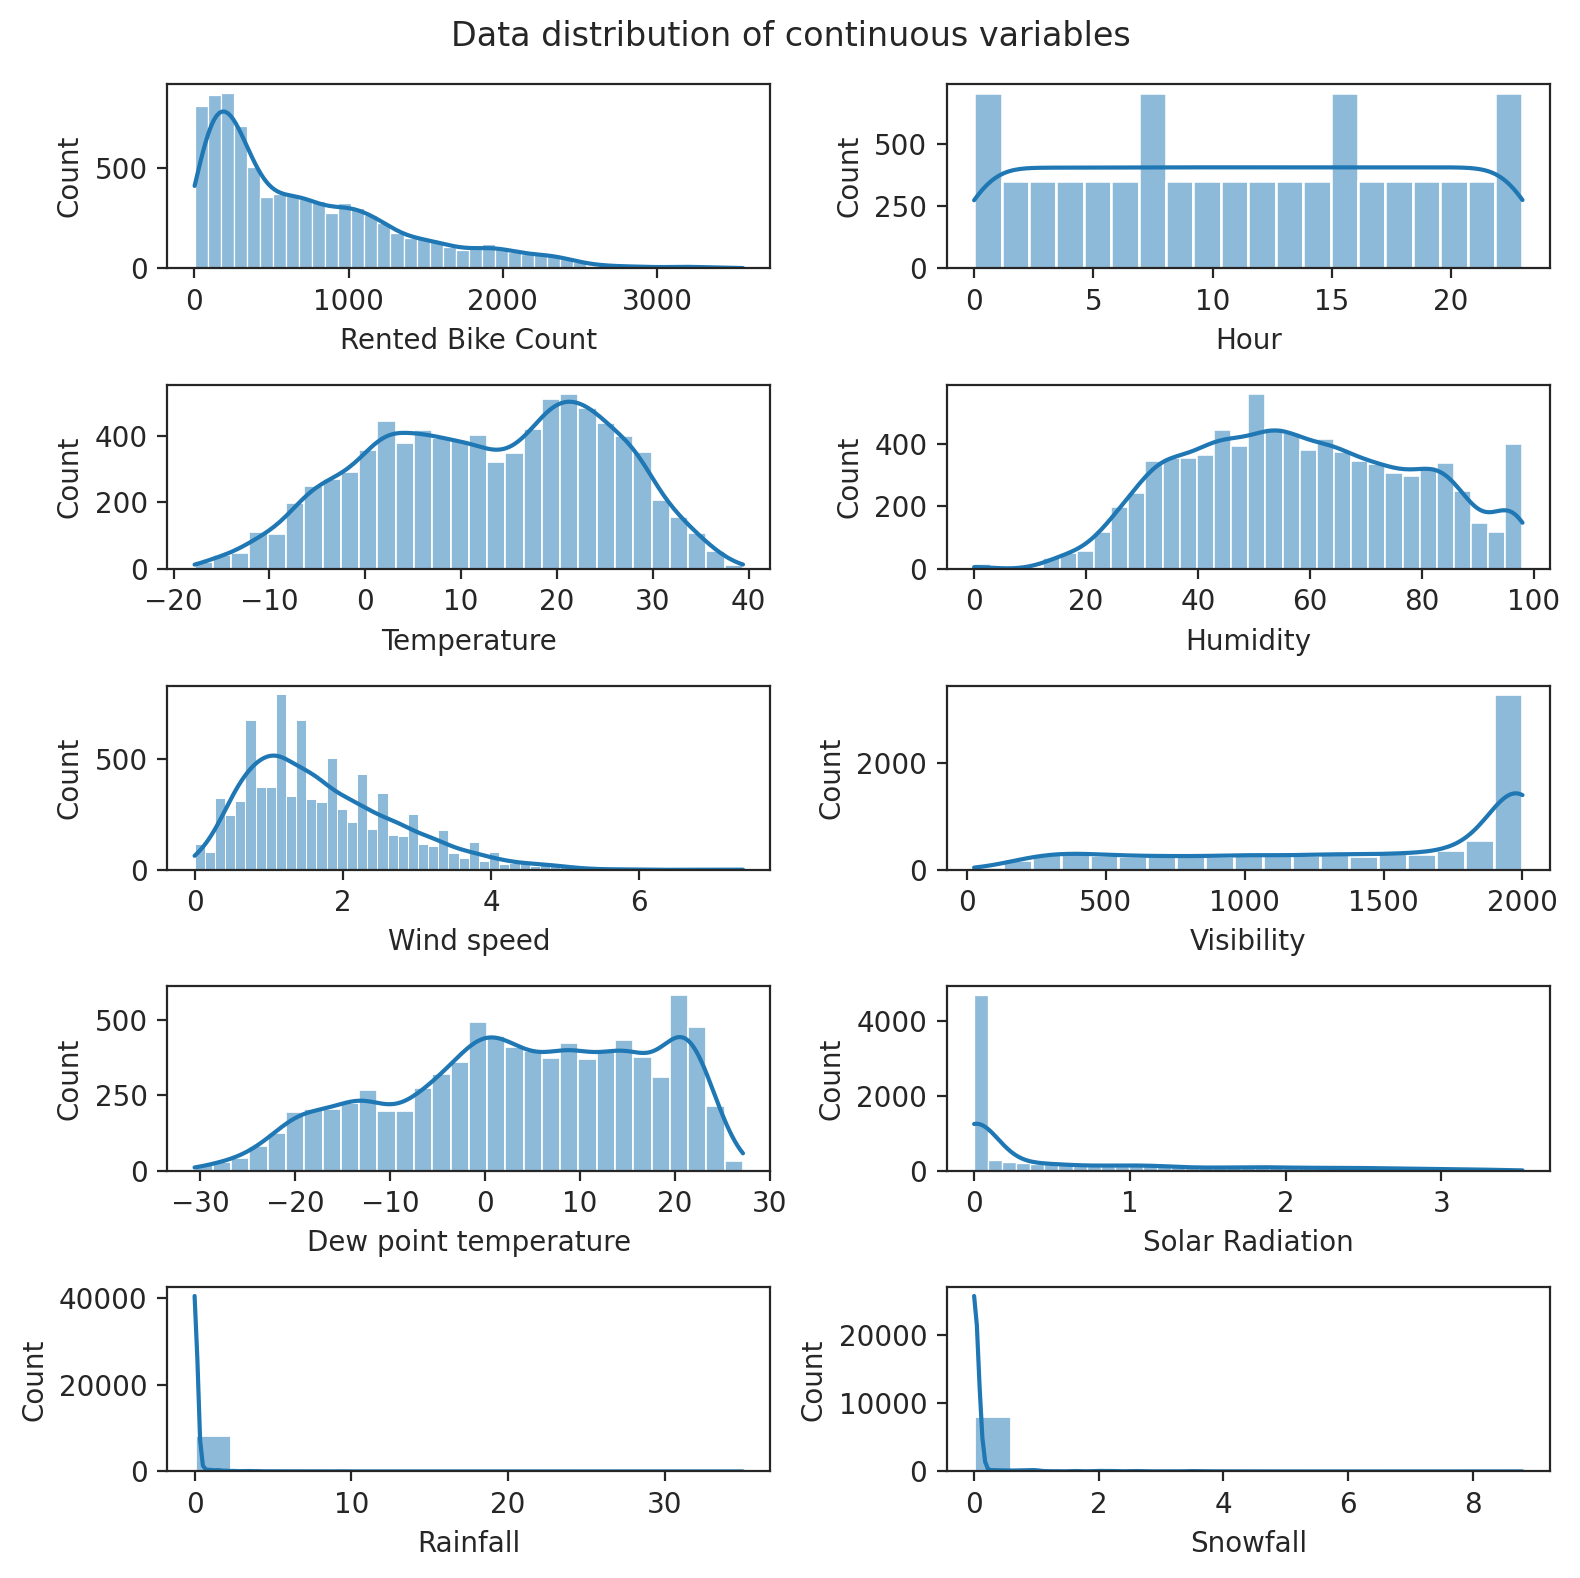

In [ ]:
plt.figure(figsize=(8, 8))
for i, col in enumerate(bikes.select_dtypes(include=['float64','int64']).columns):
    ax = plt.subplot(5,2, i+1)
    sns.histplot(data=bikes, x=col, ax=ax, kde=True)
plt.suptitle('Data distribution of continuous variables')
plt.tight_layout()

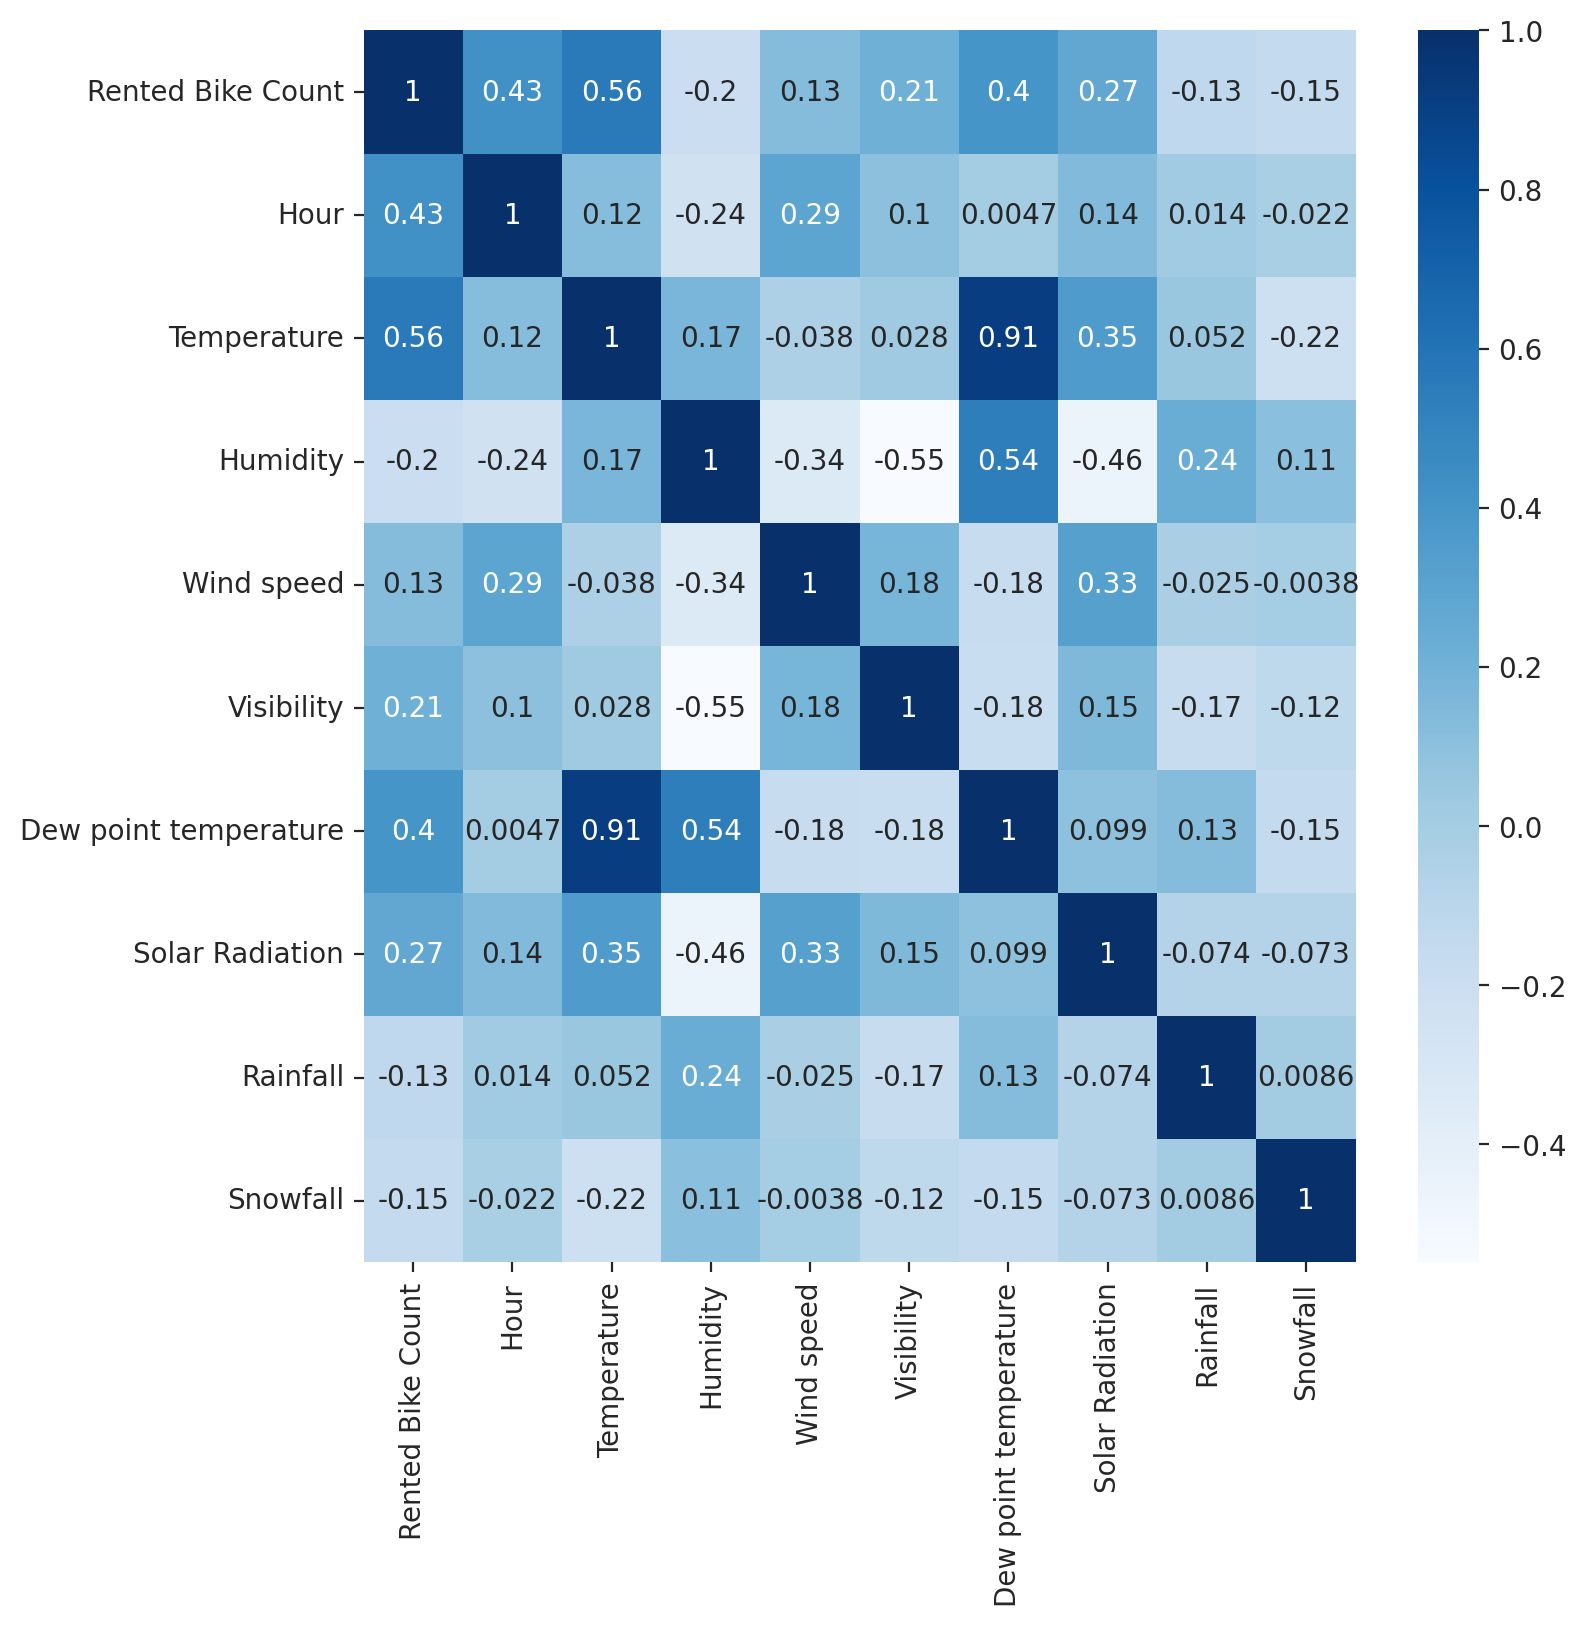

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(bikes.select_dtypes(include=['float64','int64']).corr(), annot=True, cmap='Blues')
plt.show()

Como vemos al estudiar la correlación entre variables, tenemos una alta correlación entre Temperature y Dew Point Temperature. Por lo que vamos a eliminar una de ellas, en concreto Dew Point Temperature.

La variable objetivo *Rented Bike count* está actualmente en formato entero (int). Aunque no es necesario convertirla a float para hacer predicciones, ya que las redes neuronales pueden manejar enteros directamente, es importante considerar que el modelo puede generar valores continuos como salida. Vamos a separar ya la respuesta para de las variables predictoras.

Además, vamos a estandarizar las variables numéricas para asegurar que tengan una media de 0 y una desviación estándar de 1, lo que mejorará el rendimiento del modelo. También codificaremos las variables categóricas utilizando técnicas como One-Hot Encoding para que puedan ser interpretadas por el modelo.

La variable *Hours* podría considerarse como una variable categórica, ya que es una secuencia cíclica. No obstante, en este caso vamos a representar la hora mediante transformaciones trigonométricas (seno y coseno). De esta manera, podemos capturar la continuidad entre la última y la primera hora del día. Para conseguir esto vamos a crear dos variables nuevas basadas en seno y coseno.


In [ ]:
y = bikes['Rented Bike Count']
bikes_variables = bikes.drop(columns=['Rented Bike Count', 'Dew point temperature'])

# Transformación
bikes_variables['Hour_sin'] = np.sin(2 * np.pi * bikes_variables['Hour'] / 24)
bikes_variables['Hour_cos'] = np.cos(2 * np.pi * bikes_variables['Hour'] / 24)
bikes_variables = bikes_variables.drop(columns=['Hour'])

# Nombres de variables numéricas
str_num_var = bikes_variables.select_dtypes(include=['float64', 'int64']).columns.values
# Eliminacion de Hour_sin y Hour_cos
str_num_var = [col for col in str_num_var if col not in ['Hour_sin', 'Hour_cos']]

# Nombres de variables categóricas
str_cat_var = bikes_variables.select_dtypes(include=['object', 'category']).columns.values
# Escalamos y codificamos
transformer = make_column_transformer(
    (StandardScaler(), str_num_var),
    # No aplicar transformación a Hour_sin y Hour_cos e incorporar a la matriz del transformer
    ('passthrough', ['Hour_sin', 'Hour_cos']),
    (OneHotEncoder(), str_cat_var),
    verbose_feature_names_out=False)

# Matriz de datos con variables preprocesadas
transformed = transformer.fit_transform(bikes_variables)
# Crear DataFrame con el resultado
bikes_df = pd.DataFrame(transformed, columns=transformer.get_feature_names_out())

Vemos las primeras muestras del dataframe.

In [ ]:
bikes_df.head()

,Temperature,Humidity,Wind speed,Visibility,Solar Radiation,Rainfall,Snowfall,Hour_sin,Hour_cos,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday
0,-1.484762,-1.032395,0.458429,0.929577,-0.654079,-0.132495,-0.174951,0.000000,1.000000,0.0,0.0,0.0,1.0,0.0,1.0
1,-1.509548,-0.983575,-0.895248,0.929577,-0.654079,-0.132495,-0.174951,0.258819,0.965926,0.0,0.0,0.0,1.0,0.0,1.0
2,-1.550858,-0.934756,-0.701865,0.929577,-0.654079,-0.132495,-0.174951,0.500000,0.866025,0.0,0.0,0.0,1.0,0.0,1.0
3,-1.567382,-0.885937,-0.798556,0.929577,-0.654079,-0.132495,-0.174951,0.707107,0.707107,0.0,0.0,0.0,1.0,0.0,1.0
4,-1.550858,-1.081214,0.555121,0.929577,-0.654079,-0.132495,-0.174951,0.866025,0.500000,0.0,0.0,0.0,1.0,0.0,1.0


Vemos ahora las columnas:

In [ ]:
bikes_df.columns

Index(['Temperature', 'Humidity', 'Wind speed', 'Visibility',
       'Solar Radiation', 'Rainfall', 'Snowfall', 'Hour_sin', 'Hour_cos',
       'Seasons_Autumn', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_Holiday', 'Holiday_No Holiday'],
      dtype='object')

Eliminamos las columnas redundantes de las variables categóricas y asignamos a X:

In [ ]:
X = bikes_df.drop(columns=['Holiday_No Holiday', 'Seasons_Winter'])

In [ ]:
X.columns

Index(['Temperature', 'Humidity', 'Wind speed', 'Visibility',
       'Solar Radiation', 'Rainfall', 'Snowfall', 'Hour_sin', 'Hour_cos',
       'Seasons_Autumn', 'Seasons_Spring', 'Seasons_Summer',
       'Holiday_Holiday'],
      dtype='object')

Dividimos los datos en entrenamiento (80%) y test (20%).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

Guardamos ahora los conjuntos generados para poder recuperarlos en sesiones posteriores.

In [ ]:
X_train.to_pickle(f'{path}/bikes_X_train.pkl')
X_test.to_pickle(f'{path}/bikes_X_test.pkl')
y_train.to_pickle(f'{path}/bikes_y_train.pkl')
y_test.to_pickle(f'{path}/bikes_y_test.pkl')

## Carga de los conjuntos de entrenamiento y test

In [ ]:
# Leemos los conjuntos de entrenamiento y test
X_train = pd.read_pickle(f'{path}/bikes_X_train.pkl')
X_test = pd.read_pickle(f'{path}/bikes_X_test.pkl')
y_train = pd.read_pickle(f'{path}/bikes_y_train.pkl')
y_test = pd.read_pickle(f'{path}/bikes_y_test.pkl')

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6772, 13)
(1693, 13)
(6772,)
(1693,)


## Modelo basal

A continuación se propone un modelo de red neuronal básico, que servirá como punto de partida para comparar los cambios de hiperparámetros.

El modelo de partida estará compuesto por:

* Una capa oculta de entrada con 8 neuronas y función de activación relu
* Una capa de salida con 1 neurona sin función de activación (estamos ante un problema de regresión).
* Función de pérdida *mse* (error cuadrático medio) con optimizador sgd
* Métrica de evaluación similaridad coseno (*cosine_similarity*), que nos da una medida de lo próximos que se encuentran los valores observados de los valores predichos por el modelo. Cuanto más cerca está el valor obtenido a 1 el modelo propuesto aproxima mejor los valores reales observados.
* En el periodo de entrenamiento consideramos un bacth size igual a 24 y 20 epochs.

In [ ]:
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_bikes_00 = keras.Sequential([
    Input(shape=(X_train.shape[1],)),  # Forma de entrada
    Dense(8, activation='relu', kernel_initializer=initializer),
    Dense(1)
])

# Resumen del modelo
print("Resumen del modelo")
print("======================")
modelo_bikes_00.summary()

# Proceso de aprendizaje
modelo_bikes_00.compile(loss = 'mse', optimizer = 'SGD', metrics = ['cosine_similarity'])

# Entrenamiento de la red
print("\n Entrenamiento de la red")
print("=============================")
history_bikes_00 = modelo_bikes_00.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = True)

# Evaluación del modelo
print("\n Evaluación de la red")
print("=========================")
test_loss_bikes_00, test_acc_bikes_00 = modelo_bikes_00.evaluate(X_test, y_test)

Resumen del modelo


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                     │ (None, 8)                   │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)


 Entrenamiento de la red
Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - cosine_similarity: nan - loss: nan
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - loss: nan
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - cosine_similarity: nan - loss: nan
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - loss: nan
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - loss: nan
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - cosine_similarity: nan - loss: nan
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - loss: nan
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - loss: nan
Epoch 9/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - loss: nan
Epoch 10/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - loss: nan
Epoch 11/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: nan - los

El resultado de la red es pésimo, por lo que vamos a cambiar de optimizador a Adam.

In [ ]:
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_bikes_00 = keras.Sequential([
    Input(shape=(X_train.shape[1],)),  # Forma de entrada
    Dense(8, activation='relu', kernel_initializer=initializer),
    Dense(1)
])

# Resumen del modelo
print("Resumen del modelo")
print("======================")
modelo_bikes_00.summary()

# Proceso de aprendizaje
modelo_bikes_00.compile(loss = 'mse', optimizer = 'Adam', metrics = ['cosine_similarity'])

# Entrenamiento de la red
print("\n Entrenamiento de la red")
print("=============================")
history_bikes_00 = modelo_bikes_00.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = True)

# Evaluación del modelo
print("\n Evaluación de la red")
print("=========================")
test_loss_bikes_00, test_acc_bikes_00 = modelo_bikes_00.evaluate(X_test, y_test)

Resumen del modelo


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_88 (Dense)                     │ (None, 8)                   │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_89 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)


 Entrenamiento de la red
Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - cosine_similarity: 0.4382 - loss: 954257.0000
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 0.9481 - loss: 977303.8750
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 0.9506 - loss: 917942.9375
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cosine_similarity: 0.9765 - loss: 905014.8750
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cosine_similarity: 0.9986 - loss: 860231.0000
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 0.9990 - loss: 829267.9375
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cosine_similarity: 1.0000 - loss: 787561.3125
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cosine_similarity: 1.0000 - loss: 740002.5625
Epoch 9/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 1.0000 - loss: 667235.5625
Epoch 10/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - cosine_similarity: 

El valor de similitud de coseno que obtenemos es muy elevado, pero también lo es la función de pérdida mse, por lo que vamos a buscar una mejor estructura.

### Experimentación con cambios a nivel de estructura


#### Misma arquitectura, cambio en número de neuronas

Primero vamos a mantener la arquitectura de la red pero modificando el número de neuronas de la capa oculta. Vamos a probar:

* Disminuir el número de neuronas a 4.
* Aumentar el número de neuronas a 16, 32, 64, 128.

In [ ]:
# Neuronas
neuronas = [4, 8, 16, 32, 64, 128]

# red neuronal
initializer = tf.keras.initializers.GlorotNormal(123)

# Bucle de cálculo
for i in neuronas:
  print("Neuronas: ", i)
  # Arquitectura de red
  bikes_model_00 = keras.Sequential([
      Input(shape=(X_train.shape[1],)),  # Forma de entrada
      Dense(i, activation='relu', kernel_initializer=initializer),
      Dense(1, activation='sigmoid')
  ])

  bikes_model_00.compile(loss = 'mse', optimizer = 'Adam', metrics = ['cosine_similarity'])

  bikes_model_00.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = False)
  test_loss, test_acc = bikes_model_00.evaluate(X_test, y_test)

Neuronas:  4
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - cosine_similarity: 1.0000 - loss: 920780.1250
Neuronas:  8
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - cosine_similarity: 1.0000 - loss: 920779.5000
Neuronas:  16
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - cosine_similarity: 1.0000 - loss: 920779.4375
Neuronas:  32
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 920779.4375
Neuronas:  64
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 920779.4375
Neuronas:  128
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 920779.4375


Este cambio en el número de neuronas no ha producido ninguna mejora. Vamos a cambiar el número de capas ahora.

#### Cambio de arquitectura, mismo número de neuronas

Ahora modificamos la arquitectura de la red, cambiando el número de capas. Vamos a probar:
* Aumentar a dos capas ocultas
* Aumentar a tres capas ocultas

In [ ]:
# Análisis con 2 capas
# inicialización de bucles
neuronas = [4, 8, 16, 32, 64, 128]

# red neuronal
initializer = tf.keras.initializers.GlorotNormal(123)
# Bucle de cálculo
for i in neuronas:
  print("Neuronas: ", i)
  # Arquitectura de red
  bikes_model_00 = keras.Sequential([
      Input(shape=(X_train.shape[1],)),  # Forma de entrada
      Dense(i, activation='relu', kernel_initializer=initializer),
      Dense(i, activation='relu', kernel_initializer=initializer),
      Dense(1)
  ])

  bikes_model_00.compile(loss = 'mse', optimizer = 'Adam', metrics = ['cosine_similarity'])

  bikes_model_00.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = False)
  test_loss, test_acc = bikes_model_00.evaluate(X_test, y_test)
  print(f'MSE: {test_loss}, Cosine similarity: {test_acc}')

Neuronas:  4
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - cosine_similarity: 1.0000 - loss: 150039.9062
MSE: 155750.171875, Cosine similarity: 1.0
Neuronas:  8
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - cosine_similarity: 1.0000 - loss: 143394.5781
MSE: 150058.984375, Cosine similarity: 1.0
Neuronas:  16
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - cosine_similarity: 1.0000 - loss: 137694.5938
MSE: 144891.390625, Cosine similarity: 1.0
Neuronas:  32
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 1.0000 - loss: 113698.9141
MSE: 119586.5859375, Cosine similarity: 1.0
Neuronas:  64
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - cosine_similarity: 0.9642 - loss: 94795.8281
MSE: 98314.6640625, Cosine similarity: 0.9657412767410278
Neuronas:  128
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - cosine_similarity: 0.9797 - loss: 84657.7891
MSE: 87796.5546875, Cosine similarity: 0.9822799563407898


Al haber aumentado el número de capas el valor de mse ha disminuido de 920779.4375 a 84657.7891 en entrenamiento y 87796.55 en test. Vamos a probar ahora con 3 capas e incluimos un valor más en el número de neuronas (256).

In [ ]:
# Análisis con 3 capas
# inicialización de bucles
neuronas = [4, 8, 16, 32, 64, 128, 256]

# red neuronal
initializer = tf.keras.initializers.GlorotNormal(123)
# Bucle de cálculo
for i in neuronas:
  print("\nNeuronas: ", i)
  # Arquitectura de red
  bikes_model_00 = keras.Sequential([
      Input(shape=(X_train.shape[1],)),  # Forma de entrada
      Dense(i, activation='relu', kernel_initializer=initializer),
      Dense(i, activation='relu', kernel_initializer=initializer),
      Dense(i, activation='relu', kernel_initializer=initializer),
      Dense(1)
  ])

  bikes_model_00.compile(loss = 'mse', optimizer = 'Adam', metrics = ['cosine_similarity'])

  bikes_model_00.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = False)
  test_loss, test_acc = bikes_model_00.evaluate(X_test, y_test)
  print("\n Evaluación de la red")
  print("=========================")
  print(f'MSE: {test_loss:.4f}, Cosine similarity: {test_acc:.4f}')


Neuronas:  4
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 138972.2188

 Evaluación de la red
MSE: 146306.5781, Cosine similarity: 1.0000

Neuronas:  8
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 122620.4766

 Evaluación de la red
MSE: 129179.1484, Cosine similarity: 1.0000

Neuronas:  16
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 1.0000 - loss: 107162.3594

 Evaluación de la red
MSE: 111965.0547, Cosine similarity: 1.0000

Neuronas:  32
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 0.9881 - loss: 83205.1953

 Evaluación de la red
MSE: 84613.6328, Cosine similarity: 0.9905

Neuronas:  64
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - cosine_similarity: 1.0000 - loss: 76181.4297

 Evaluación de la red
MSE: 79446.2969, Cosine similarity: 1.0000

Neuronas:  128
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - cosine_similarity: 0.9969 - loss: 56878.4844

 Evaluación de la red
MSE: 59814.9414, Cosine similarity: 

De acuerdo con los resultados, el mejor modelo consta de 3 capas ocultas con 256 neuronas cada una, con una similitud de coseno de 1.0000 y un valor de MSE de 51699.4492. Vamos ahora a entrenar ese modelo y guardarlo.

In [ ]:
initializer = tf.keras.initializers.GlorotNormal(123)

# Arquitectura de red
modelo_bikes_00 = keras.Sequential([
    Input(shape=(X_train.shape[1],)),  # Forma de entrada
    Dense(256, activation='relu', kernel_initializer=initializer),
    Dense(256, activation='relu', kernel_initializer=initializer),
    Dense(256, activation='relu', kernel_initializer=initializer),
    Dense(1)
])

# Resumen del modelo
print("Resumen del modelo")
print("======================")
modelo_bikes_00.summary()

# Proceso de aprendizaje
modelo_bikes_00.compile(loss = 'mse', optimizer = 'Adam', metrics = ['cosine_similarity'])

# Entrenamiento de la red
print("\n Entrenamiento de la red")
print("=============================")
history_bikes_00 = modelo_bikes_00.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = True)

# Evaluación del modelo
print("\n Evaluación de la red")
print("=========================")
test_loss_bikes_00, test_acc_bikes_00 = modelo_bikes_00.evaluate(X_test, y_test)

Resumen del modelo


Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_202 (Dense)                    │ (None, 256)                 │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_203 (Dense)                    │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_204 (Dense)                    │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_205 (Dense)                    │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 135,425 (529.00 KB)

 Trainable params: 135,425 (529.00 KB)

 Non-trainable params: 0 (0.00 B)


 Entrenamiento de la red
Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - cosine_similarity: 0.9799 - loss: 507044.8438
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cosine_similarity: 0.9984 - loss: 144826.6719
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - cosine_similarity: 1.0000 - loss: 119223.0234
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - cosine_similarity: 1.0000 - loss: 101242.0938
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 1.0000 - loss: 88610.8672
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 1.0000 - loss: 77625.5078
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 1.0000 - loss: 70221.5469
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 1.0000 - loss: 68051.4297
Epoch 9/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 1.0000 - loss: 59935.0312
Epoch 10/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - cosine_similarity: 1.000

Guardamos el modelo de red neuronal entrenado.

In [ ]:
# Guardamos el modelo
modelo_bikes_00.save(f'{path}/model_bikes_v01.keras')

## Mejora del modelo basal

Para mejorar el modelo basal desarrollado, podemos modificar los hiperparámetros de la red como son el número de *epochs*, el *batch_size* y el *learning_rate*. Además, vamos a comparar 2 optimizadores (Adam, Nadam y RMSprop). Vamos a utilizar:

* Optimizador Adam con learning rates 0.001, 0.01, y 0.1.
* Optimizador Nadam con learning rates 0.001, 0.01, y 0.1. Nadam es una variante de Adam que incluye la actualización del momentum en el cálculo de gradientes.
* Optimizador RMSprop con learning rates 0.001, 0.05, 0.01, y 0.1 con momentum.

No utilizamos SGD porque antes no hemos obtenido buenos resultados.

En primer lugar cargamos el modelo que hemos generado de base y los conjuntos de entrenamiento y test.

In [ ]:
bikes_model = keras.models.load_model(f'{path}/model_bikes_v01.keras')

In [ ]:
X_train = pd.read_pickle(f'{path}/bikes_X_train.pkl')
X_test = pd.read_pickle(f'{path}/bikes_X_test.pkl')
y_train = pd.read_pickle(f'{path}/bikes_y_train.pkl')
y_test = pd.read_pickle(f'{path}/bikes_y_test.pkl')

### Optimizador Adam

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

# Optimizador Adam
learning = [0.001, 0.05, 0.01, 0.1]

for lr in learning:
  bikes_model.compile(loss = 'mse',
                         optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
                         metrics = ['cosine_similarity'])
  bikes_model.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = False)
  test_loss, test_acc = bikes_model.evaluate(X_test, y_test)
  print("\n Evaluación de la red")
  print("=========================")
  print(f'MSE: {test_loss:.4f}, Cosine similarity: {test_acc:.4f}')

# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 45548.5547

 Evaluación de la red
MSE: 51777.2617, Cosine similarity: 1.0000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - cosine_similarity: 1.0000 - loss: 55801.5312

 Evaluación de la red
MSE: 59125.4609, Cosine similarity: 1.0000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - cosine_similarity: 1.0000 - loss: 49472.6758

 Evaluación de la red
MSE: 54170.7500, Cosine similarity: 1.0000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 1.0000 - loss: 50190.5039

 Evaluación de la red
MSE: 53651.7422, Cosine similarity: 1.0000
Tiempo de ejecución Colab TPU: 0:01:12.397737


### Optimizador Nadam

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

# Optimizador Adam
learning = [0.001, 0.05, 0.01, 0.1]

for lr in learning:
  bikes_model.compile(loss = 'mse',
                         optimizer = tf.keras.optimizers.Nadam(learning_rate=lr),
                         metrics = ['cosine_similarity'])
  bikes_model.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = False)
  test_loss, test_acc = bikes_model.evaluate(X_test, y_test)
  print("\n Evaluación de la red")
  print("=========================")
  print(f'MSE: {test_loss:.4f}, Cosine similarity: {test_acc:.4f}\n')


# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 47997.3398

 Evaluación de la red
MSE: 52872.7852, Cosine similarity: 1.0000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - cosine_similarity: 1.0000 - loss: 50428.6094

 Evaluación de la red
MSE: 54644.0273, Cosine similarity: 1.0000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 51783.2422

 Evaluación de la red
MSE: 58346.6562, Cosine similarity: 1.0000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - cosine_similarity: 1.0000 - loss: 53403.3320

 Evaluación de la red
MSE: 57190.6992, Cosine similarity: 1.0000
Tiempo de ejecución Colab TPU: 0:01:15.447712


### Optimizador RMSProp

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

# Optimizador RMSprop
learning = [0.001, 0.05, 0.01, 0.1]

for lr in learning:
  bikes_model.compile(loss = 'mse',
                         optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, momentum = 0.9),
                         metrics = ['cosine_similarity'])
  bikes_model.fit(X_train, y_train, batch_size = 24, epochs = 20, verbose = False)
  test_loss, test_acc = bikes_model.evaluate(X_test, y_test)
  print("\n Evaluación de la red")
  print("=========================")
  print(f'MSE: {test_loss:.4f}, Cosine similarity: {test_acc:.4f}\n')

# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 52102.4062

 Evaluación de la red
MSE: 57343.6680, Cosine similarity: 1.0000

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 70094.2031

 Evaluación de la red
MSE: 73354.6719, Cosine similarity: 1.0000

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - cosine_similarity: 1.0000 - loss: 70389.0781

 Evaluación de la red
MSE: 71394.0234, Cosine similarity: 1.0000

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - cosine_similarity: 1.0000 - loss: 394873.7188

 Evaluación de la red
MSE: 393349.5625, Cosine similarity: 1.0000

Tiempo de ejecución Colab TPU: 0:01:03.583944


Del estudio realizado parace que la solución con Adam y learning rate de 0.001 es la que porporciona mejores resultados (menor loss y cosine_similarity de 1.000).

Utilizamos esa combinación como nuevo modelo para estudiar la influencia de epochs y el batch size. En este caso utilizamos los siguientes valores de los hiperparámetros:

* epochs = 10 de a 50 en incrementos de 10,
* batch_size = 4, 8, 16, 32, 64, 128 y 256.

In [ ]:
# inicialización de bucles
epocas = range(10,51,10)
idx = range(0,len(epocas))
batch = [4, 8, 16, 32, 64, 128, 256]
jdx = range(0,len(batch))

loss = np.zeros(shape=(len(epocas),len(batch)))
accu = np.zeros(shape=(len(epocas),len(batch)))

# red neuronal

# Bucle de cálculo
for i in idx:
  for j in jdx:
    print("Epocas: ", epocas[i], "; Batch: ", batch[j])
    bikes_model.compile(loss = 'mse',
                         optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                         metrics = ['cosine_similarity'])
    bikes_model.fit(X_train, y_train, batch_size = batch[j], epochs = epocas[i], verbose = False)
    test_loss, test_acc = bikes_model.evaluate(X_test, y_test)
    print("\n Evaluación de la red")
    print(f'MSE: {test_loss:.4f}, Cosine similarity: {test_acc:.4f}')
    print("=========================\n")
    loss[i,j] = test_loss
    accu[i,j] = test_acc

Epocas:  10 ; Batch:  4
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - cosine_similarity: 1.0000 - loss: 394495.5938

 Evaluación de la red
MSE: 392813.7812, Cosine similarity: 1.0000

Epocas:  10 ; Batch:  8
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - cosine_similarity: 1.0000 - loss: 394458.3125

 Evaluación de la red
MSE: 392745.4062, Cosine similarity: 1.0000

Epocas:  10 ; Batch:  16
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 394449.1562

 Evaluación de la red
MSE: 392726.6562, Cosine similarity: 1.0000

Epocas:  10 ; Batch:  32
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - cosine_similarity: 1.0000 - loss: 394444.5625

 Evaluación de la red
MSE: 392716.6562, Cosine similarity: 1.0000

Epocas:  10 ; Batch:  64
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - cosine_similarity: 1.0000 - loss: 394443.8438

 Evaluación de la red
MSE: 392715.0312, Cosine similarity: 1.0000

Epocas:  10 ; Batch:  128
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - cosine_similarity: 1.0000 - loss: 3

Los valores obtenidos parecen todos bastante similares, por lo que no parece haber influencia de estos parametros. Asi, nos quedamos con los que habíamos empleado inicialmente.

De acuerdo con los resultados obtenidos, mejor optimizador ha sido ***Adam***, con un learning_rate de ***0.001***. Respecto al batch_size y las epocas, al no haber influencia de estos hiperparámetros vamos a mantener los que hemos usado al inicio, que proporcionan buen rendimiento.

In [ ]:
b_size = 24
epocas = 20

In [ ]:
# Para evaluar tiempo de ejecución
start_time = datetime.now()

bikes_model.compile(loss = 'mse',
                        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                        metrics = ['cosine_similarity'])

history = bikes_model.fit(X_train, y_train, batch_size = b_size, epochs = epocas, verbose = False)
test_loss, test_acc = bikes_model.evaluate(X_test, y_test)
print("\n Evaluación de la red")
print(f'MSE: {test_loss:.4f}, Cosine similarity: {test_acc:.4f}')
print("=========================\n")

# Calculo del tiempo de ejecución
end_time = datetime.now()
print('Tiempo de ejecución Colab TPU: {}'.format(end_time - start_time))

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - cosine_similarity: 0.9995 - loss: 47121.4258

 Evaluación de la red
MSE: 51371.0898, Cosine similarity: 0.9976

Tiempo de ejecución Colab TPU: 0:00:18.737296


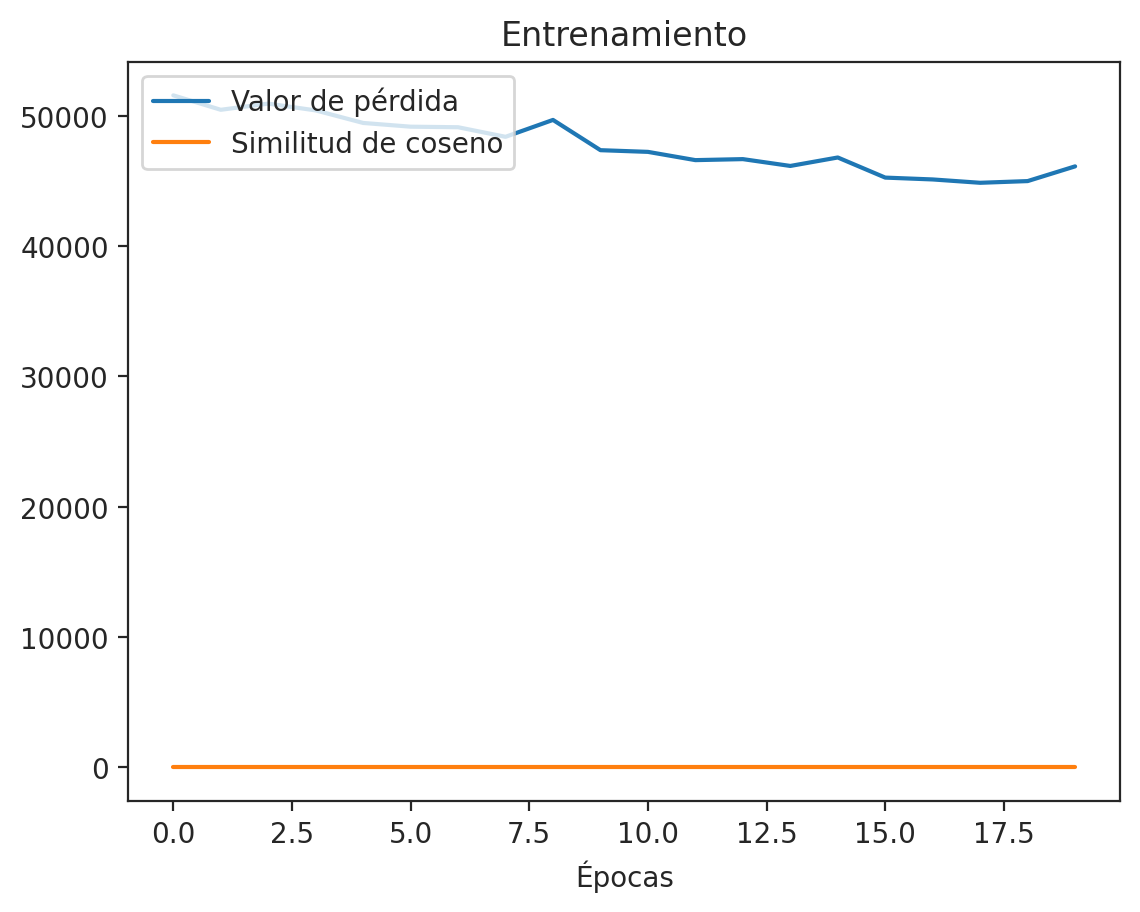

In [ ]:
# Gráficas
plot_train_history(history)

Guardamos el modelo.

In [ ]:
# Guardamos el modelo
modelo_bikes_00.save(f'{path}/model_bikes_v02.keras')

Como vemos, a pesar de todo el estudio realizado, los resultados alcanzados no han sido satisfactios del todo ya que el valor de MSE es muy elevado. Vamos a probar con modelos más sencillos como la regresión lineal y el árbol de decisión.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

In [ ]:
y_test = y_test.ravel()

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_test_2d = y_test.reshape(-1, 1)
y_pred_2d = y_pred.reshape(-1, 1)

cos_sim = cosine_similarity(y_test_2d, y_pred_2d)
mse = mean_squared_error(y_test, y_pred)

print(f'Model cosine similarity : {cos_sim[0,0]:.4f}')
print(f'Model MSE : {mse:.4f}')

Model cosine similarity : 1.0000
Model MSE : 176375.9801


In [ ]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_test_2d = y_test.reshape(-1, 1)
y_pred_2d = y_pred.reshape(-1, 1)

cos_sim = cosine_similarity(y_test_2d, y_pred_2d)
mse = mean_squared_error(y_test, y_pred)

print(f'Model cosine similarity : {cos_sim[0,0]:.4f}')
print(f'Model MSE : {mse:.4f}')

Model cosine similarity : 1.0000
Model MSE : 96008.3568


## Conclusiones



En este trabajo se han comparado diferentes arquitecturas e hiperparámetros de redes neuronales para predecir el número de bicicletas alquiladas. El rendimiento de los modelos se ha evaluado utilizando dos métricas principales: la similitud de coseno y el error cuadrático medio (MSE).

Las similitudes de coseno alcanzadas han sido muy elevadas, lo que indica correspondencia en la dirección de las predicciones en relación con los valores reales. No obstante, los valores de MSE han sido insatisfactorios, lo que indica que presentan errores significativos en la magnitud de las predicciones.

Finalmente se han realizado pruebas con modelos de regresión más sencillos, obteniendo unos resultados similares en cuanto a similitud de coseno, pero empeorando los valores de MSE. Así, los modelos más complejos como son las redes neuronales, permiten ajustar mejor la dirección de las predicciones.